## Understanding Extreme Value Theory and Extreme Value Distributions

The main challenge of extreme values is that that there are **only a few observations** from which credible, reliable and analytical model can be built.<br>

Obviously, there are extreme values that have never been observed, but that does not mean there's no **chance of occurrence** in the future. (these are the typical the *black swan events*)<br>
These challenges are tackled by assuming a central distribution generally, but **choosing a distribution arbitrarily is ill-suited to handle extremes** as the distribution will tend to accommodate the more central observations rather than the extreme observations. 

and this is why we have **EVT or Extreme Value Theory**.

EVT helps in assessing the risk of extreme events, such as natural disasters (e.g., floods, hurricanes, earthquakes) or financial market crashes. By modeling the tail of the distribution, EVT provides insights into the likelihood and potential severity of these events.

In [163]:
# PS: I coudln't find projects/repos that really shows how to use genextreme to explore extreme value theory. So I created a notebook to test out the distribution and its fitting capabilities. I will be using synthetic data for this purpose, but the same code can be applied to real-world data as well.
## While the scipy.genextreme documentation was a starting point, i struggled to find a guide that explained the "how" and "why" properly. 

# This notebook is a compilation of tests and explorations pulling from statistics lectures on YouTube, CFA reading material, and the scipy documentation. The goal is to understand how to use the genextreme distribution for modeling extreme events, and to validate its fitting capabilities using synthetic data. 

**Extreme Value Theory**
- 1st moment - mean/average 
- 2nd moment - measure of dispersion/variance. - volatility
- 3rd moment - measure of the tilt/skew. 
- 4th moment - measure of the tail weight and its density.

It is well understood that asset returns are fat tailed, which means that the normal can not adequately capture the probability that will end up in 4th moment where the losses are severe.

EVTs describe the distribution that characterizes the losses specifically on the tail, it zooms in on the tail, that has its own distribution. 

**GEV approaches**
-  Block Maxima (tends to fit GEV) - *max of each block*
    - *(Wilmott's Distribution of maxima/minima).*
-  Peaks over Threshold (POT) (~GPD) 

In [1]:
import numpy as np
from scipy.stats import genextreme
import pandas as pd
import matplotlib.pyplot as plt
import random

In [5]:
# generating 10,000 random integers between -20 and 20
nums = [random.randint(-20,20) for _ in range(10000)]

# preparing our sample data for the genextreme distribution
data = np.array([nums])

**Part 1: Understanding the parameters**

The Generalized Extreme Value (GEV) distribution has 3 parameters:
- c (shape, ξ): Controls the tail behavior
    - if shape > 0: its a **frechet** type curve (heavy tail) 
    - if shape = 0: it becomes a **gumbel** distribution ('light tail' used for modelling max/min values)
    - if shape < 0: its a **weibull** type curve ('lighter tail' - bounded tail)

*In risk management, we focus on cases 1 and 2. Distributions where ξ < 0 do not apppear in financial models*

- loc (location, μ): Shifts the distribution left/right
- scale (scale, σ): Stretches/compresses the distribution
    - larger values make the distribution wider and flatter.
    - smaller values make the distribution narrower and steeper.

In [7]:
shape, loc, scale = genextreme.fit(data)

in Extreme Value Distributions, the parameters shape, loc and scale control the behavior of the distribution. 

The probability density function for GEV distribution with μ (location), σ (scale) and ξ (shape) is 

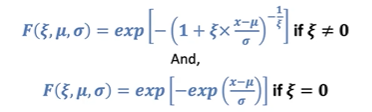

In [8]:
print("Fit parameters: ")
print(f"shape : {shape:.4f}")  # Controls the tail behavior, (how extreme the extremes can be)
print(f"loc : {loc:.4f}")   # location parameter. shifts the entire distribution left or right on the number line. Acts as the center or starting point of the distribution. 
print(f"scale : {scale:.4f}")  # spread or the width of the distribution. (must be +ve)

Fit parameters: 
shape : 0.4268
loc : -3.3618
scale : 12.2674


In [9]:
# creating a simple GEV distribution.
gev = genextreme(c=shape, loc=loc, scale=scale)

In [14]:
print(f"Created GEV with fit parameters : shape ({shape:.2f}), location({loc:.2f}) and scale ({scale:.2f}).")
print(f"\t - Mean                :  {gev.mean():.2f}")
print(f"\t - Variance            :  {gev.var():.2f}")
print(f"\t - Standard Deviation  :  {gev.std():.2f}")

Created GEV with fit parameters : shape (0.43), location(-3.36) and scale (12.27).
	 - Mean                :  -0.09
	 - Variance            :  133.41
	 - Standard Deviation  :  11.55


In [20]:
samples = gev.rvs(size=1000000)  # generates a random sample based on the size, .rvs() stands for random variables.
print(f"Generated {len(samples)} random samples...")

Generated 1000000 random samples...


In [23]:
print(f"Sample mean     : {samples.mean():.2f}")
print(f"Sample stdev    : {samples.std():.2f}")
print(f"First 5 samples : {samples[:5]}")

Sample mean     : -0.09
Sample stdev    : 11.55
First 5 samples : [-19.42423527   9.98078101   4.01334984  17.142701   -20.69551797]


**Part 2: Probability Density Function** <br>

PDF tells you the probability density at each point. <br>
Higher pdf = more likely to observe values near that point. 

In [25]:
x = 12.5 

In [26]:
pdf_value = gev.pdf(x)
print(f"PDF at {x} is {pdf_value:.4f}")

PDF at 12.5 is 0.0238


In [37]:
# the PDF value at x=12.5 is 0.0238, which indicates that the probability density of observing a value around 12.5 is ~2.4% low according to our fitted GEV distribution. 
# this suggests that 12.5 is an extreme value in the context of our data, and occurrences around this value are rare.

In [77]:
# defining specific points
x_points = np.array([1, 2, 5, 10, 15, 20, 25, 50])

# calculating PDFs for the points 
pdf_values = gev.pdf(x_points)

for xi, pi in zip(x_points, pdf_values): 
    print(f" PDF({xi})      :   {pi:.4f}") 

 PDF(1)      :   0.0331
 PDF(2)      :   0.0333
 PDF(5)      :   0.0329
 PDF(10)      :   0.0279
 PDF(15)      :   0.0189
 PDF(20)      :   0.0084
 PDF(25)      :   0.0002
 PDF(50)      :   0.0000


interpreting the PDF value: 

The PDF value at a specific point (like x=12.5) represents the relative likelihood of observing that exact value in the distribution. A higher PDF value indicates that the value is more likely to occur, while a lower PDF value suggests it is less likely. However, since the PDF can be greater than 1 for certain distributions, it is not a probability but rather a density. To find the probability of observing a value within a range, you would need to integrate the PDF over that range.

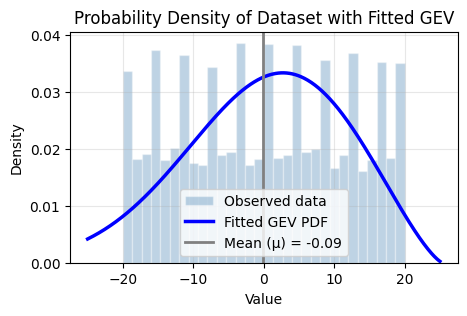

In [73]:
# creating the whole range of what's in the data, adding +-5 as buffer for better viz. 
x_vals = np.linspace(data.min() - 5, data.max() + 5, 500)

# calculating the PDF values for the range of x_vals
pdf_vals = gev.pdf(x_vals)

plt.figure(figsize=(5, 3))
plt.hist(data.ravel(), bins=30, density=True, alpha=0.35, color="steelblue", edgecolor="white", label="Observed data") # distribution
plt.plot(x_vals, pdf_vals, color="blue", lw=2.5, label="Fitted GEV PDF") # pdf line
plt.axvline(mu, color="grey", lw=2, label=f"Mean (μ) = {mu:.2f}") # mean line

plt.title("Probability Density of Dataset with Fitted GEV")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

**Part 3: Cumulative Distribution Function**

gives you P(X <= x) - probability of being less than or equal to x

In [42]:
x = 12 

In [43]:
cdf_value = gev.cdf(x) # calculate cdf using the .cdf() method of the GEV distribution, which gives the cumulative probability up to x.

print(f"CDF at {x} : {cdf_value:.4f}")

CDF at 12 : 0.8464


In [45]:
# what's the probability of exceeding a threshold? 

threshold = 18.5 # threshold value to check exceedance probability

prob_exceed = 1 - gev.cdf(threshold) # 

print(f"Probability of exceeding a threshold of {threshold}     :   {prob_exceed*100:.2f}%")

Probability of exceeding a threshold of 18.5     :   3.45%


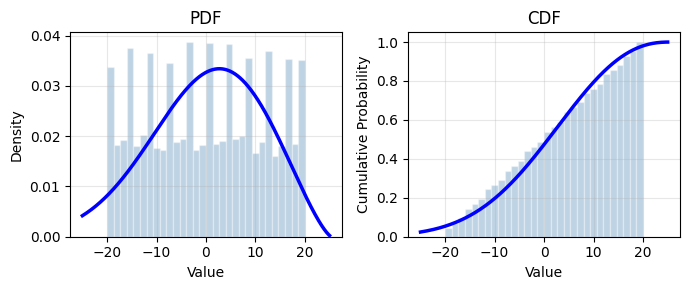

In [90]:
# 1x2 plot: PDF (left) and CDF (right) with matching style
cdf_vals = gev.cdf(x_vals)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Probability Distribution Function (PDF) --- 

axes[0].hist(data.ravel(), bins=30, density=True, alpha=0.35, color="steelblue", edgecolor="white", label="Observed data")
axes[0].plot(x_vals, pdf_vals, color="blue", lw=2.5, label="Fitted GEV PDF")
axes[0].set_title("PDF")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.3)


# Cumulative Distribution Function (CDF) ---

axes[1].hist(data.ravel(), bins=30, density=True, cumulative=True, alpha=0.35, color="steelblue", edgecolor="white", label="Observed data (cumulative)")
axes[1].plot(x_vals, cdf_vals, color="blue", lw=2.5, label="Fitted GEV CDF")
axes[1].set_title("CDF")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative Probability")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Part 4: Percent Point Function**

PPF answers, What value corresponds to this probability? 
Also called quantiles or percentiles. 

**GEV quantiles** 

we can obtain the quantiles associated with the GEV distribution as follows: 

*x = μ - σ/ξ[1-(-ln(p)**-ξ)]* when ξ > 0 

and 

*x = μ - σln[-ln(p)]* when ξ = 0

where p = chosen cumulative probability and x = observed value associated with pth quantile.

    

In [91]:
# Example: 
# Get the 95th percentile of a GEV distribution
value = genextreme.ppf(0.95, c=0.1, loc=0, scale=1)
print(f"95th percentile     :    {value:.2f}")


95th percentile     :    2.57


The probabilities  refer to the probabilities associated with the extreme loss distribution, and have nothing to do with the **'parent' loss distribution** from which the extreme losses are drawn. <br>
The 5th percentile for example is the cut-off point between the **lowest 5% of the extreme (high) losses** and the **highest 95% of the extreme (high) losses**. **it is not the 5th percentile point of the parent distribution.**

In [93]:
p95 = gev.ppf(0.95)

print(f"95th percentile     : {p95:.2f}")
print(f"Meaning             : 95% of values are below {p95:.2f}")

95th percentile     : 17.29
Meaning             : 95% of values are below 17.29


In [94]:
quantiles = [0.01, 0.25, 0.50, 0.75, 0.90, 0.99]

for q in quantiles:
    value = gev.ppf(q)
    print(f"{q*100:.0f} percentile  :   {value:.2f}")

1 percentile  :   -29.78
25 percentile  :   -7.66
50 percentile  :   0.80
75 percentile  :   8.49
90 percentile  :   14.38
99 percentile  :   21.35


**Part 5: Fitting Data to GEV distribution**

Given real data, find the best-fit GEV parameter

Let's simulate some extreme event like annual maximum precipitation and see how the GEV distribution can be used to model it.

In [99]:
# simulate some extreme event data

true_c, true_loc, true_scale = -0.2, 50, 10 

real_data = genextreme.rvs(c=true_c, loc=true_loc, scale=true_scale, size=100)
# .rvs() method generates random variates of the specified distribution. Here, we are generating 100 random samples from a GEV distribution with the specified shape (c), location (loc), and scale parameters.
print(f"Fitting GEV to {len(real_data)} data points..")

Fitting GEV to 100 data points..


In [101]:
print(real_data)

[ 50.80795887  50.50677005  47.31928131  64.7124108   46.45179271
  50.94337171  57.02200831  84.80676463  58.89911634  39.85461363
  44.04231696  49.21237911  42.75717517  51.79433243  64.68188553
  42.43207394  60.73507174  49.62322343  59.48206905  46.936259
  39.44908918  53.0094722   48.25157414  55.49046228 230.69315326
  51.93073836  47.62278789  63.20590001  86.43502507  55.8448198
  69.85516045  49.85256361  57.71800765  56.62822321  63.62011657
  39.23403809  47.10683101  54.06165471  38.11731887  56.72355331
  57.90895166  44.11574539  54.01388532  42.11222791  48.33587506
  46.22833304  49.07802594  60.10784806  47.82337702  52.14302461
  43.51666998  45.07979727  40.9787995   90.47202016  73.15607999
  47.03386692  77.88608037  74.57402968  44.08080696  59.53241291
  57.2903917   51.15985524  53.90754819  53.4708007   61.27940913
  46.03920747  39.31055415  53.67713949  56.22352689  77.05843695
  44.6483527   59.02714234  38.6448447   66.31817065  94.73641318
  56.55166444

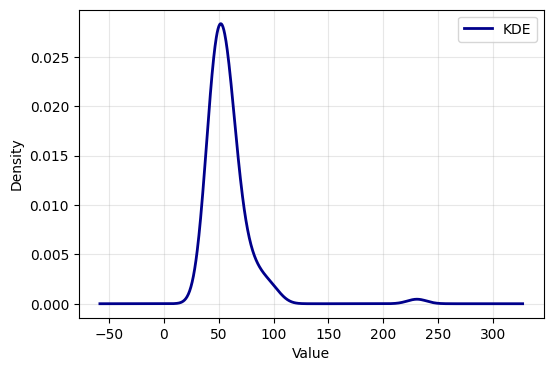

In [131]:
plt.figure(figsize=(6, 4))
pd.Series(real_data).plot(kind="density", color="darkblue", lw=2, label="KDE")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [105]:
# fit the distribution now. 
fitted_c, fitted_loc, fitted_scale = genextreme.fit(real_data)

print(f"True parameters     :    shape({true_c:.3f}), location({true_loc:.2f}) and scale({true_scale:.2f}).")
print(f"Fitted parameters   :    shape({fitted_c:.3f}), location({fitted_loc:.2f}) and scale({fitted_scale:.2f}).")

True parameters     :    shape(-0.200), location(50.00) and scale(10.00).
Fitted parameters   :    shape(-0.249), location(49.68) and scale(9.19).


In [106]:
# creating fitted distribution.
fitted_gev = genextreme(c=fitted_c, loc=fitted_loc, scale=fitted_scale)

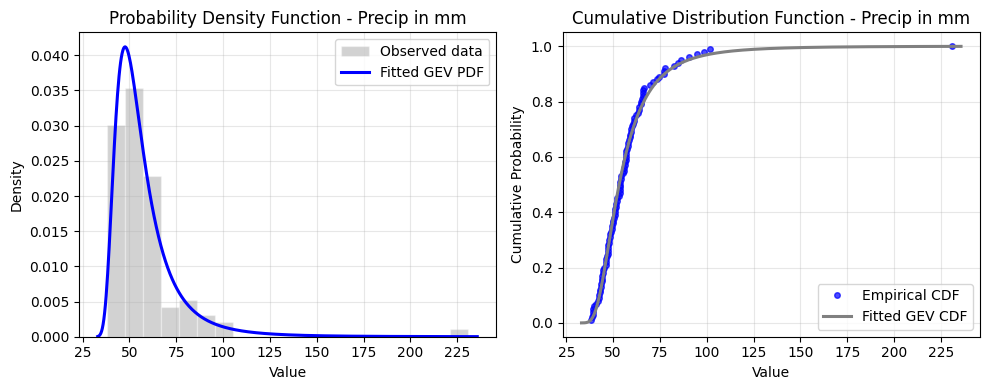

In [141]:
# PDF and CDF plots for real_data using the fitted GEV (fitted_gev)

x_real = np.linspace(real_data.min() - 5, real_data.max() + 5, 500)
pdf_real = fitted_gev.pdf(x_real)
cdf_real = fitted_gev.cdf(x_real)

# Empirical CDF
sorted_real = np.sort(real_data)
empirical_cdf_real = np.arange(1, len(sorted_real) + 1) / len(sorted_real)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# PDF
axes[0].hist(real_data, bins=20, density=True, alpha=0.35, color="grey", edgecolor="white", label="Observed data")
axes[0].plot(x_real, pdf_real, color="blue", lw=2.2, label="Fitted GEV PDF")
axes[0].set_title("Probability Density Function - Precip in mm")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.3)
axes[0].legend()

# CDF
axes[1].plot(sorted_real, empirical_cdf_real, "o", ms=4, alpha=0.7, color="blue", label="Empirical CDF")
axes[1].plot(x_real, cdf_real, color="grey", lw=2.2, label="Fitted GEV CDF")
axes[1].set_title("Cumulative Distribution Function - Precip in mm")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative Probability")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Calculating **Return Periods**

Helps to calculate once in 'n' year events.  <br>
If return period = t, the probability of exceeding in any year = 1/t.

In [109]:
def calc_return_levels(gev_dist, return_period):
    """ 
    calculate the value expected to be exceeded once every T years. 
    """
    prob_exceed = 1/return_period
    prob_not_exceed = 1-prob_exceed
    
    return gev_dist.ppf(prob_not_exceed)

In [125]:
# defining the return periods..
return_periods = np.array([5,10,25,50,100, 250, 500])

print("Return Period Analysis","-"*75)
for T in return_periods:
    level = calc_return_levels(fitted_gev, T)
    print(f"   {T}-year return level        :       {level:.2f}", f"(Value exceeded on average once every {T} years)")

Return Period Analysis ---------------------------------------------------------------------------
   5-year return level        :       66.38 (Value exceeded on average once every 5 years)
   10-year return level        :       77.39 (Value exceeded on average once every 10 years)
   25-year return level        :       94.60 (Value exceeded on average once every 25 years)
   50-year return level        :       110.25 (Value exceeded on average once every 50 years)
   100-year return level        :       128.75 (Value exceeded on average once every 100 years)
   250-year return level        :       158.57 (Value exceeded on average once every 250 years)
   500-year return level        :       186.07 (Value exceeded on average once every 500 years)


#### Goodness of the fit using KS Test<br>
Let's check how well the fitted distribution matches the data.

In [144]:
from scipy.stats import kstest  # Kolmogrov-Smirnov test

The **Kolmogorov-Smirnov** (KS) test is significant because it provides a quantitative measure of how well a theoretical distribution (like GEV) models real-world data. This is crucial for making informed decisions in risk management, infrastructure design, and adaptation strategies.

In [145]:
ks_stat, p_value = kstest(real_data, lambda x: fitted_gev.cdf(x))

In [155]:
print("Kolmogrov-Smirnov Test")
print(f"\tKS statistic    : {ks_stat:.4f}") 
print(f"\tp-value         : {p_value:.4f}") 

Kolmogrov-Smirnov Test
	KS statistic    : 0.0509
	p-value         : 0.9463


In [157]:
if p_value > 0.05:
    print("good fit (p>0.05)")
else:
    print("poor fit (p<=0.05)")

good fit (p>0.05)


The p-value (0.94) is greater than 0.05, indicating that the GEV distribution is a good fit for the data. This suggests that the GEV model can be used to estimate probabilities of extreme rainfall events, such as 100-year return levels.

#### Using the **Inverse Survival Function (ISF)**

Inverse Survival Function (ISF) is used to calculate the value of the random variable to a given survival probability. 

*P(X>x) = 1 - F(x), where F(x) is the CDF*

ISF gives the value fo the variable at specific "exceedance probability". It is used in extreme value analysis for determining the return levels associated with specific return periods. 
**The return level is the value expected to be exceeded once, on average, in a specified number of years.**

In [160]:
# now that we have the parameters, we can compute the return levels for different return periods (5,10,25,50 years..) by using the inverse survival function (ISF)

# defining return periods
return_periods = np.array([5,10,25,50,100])  

# calculate return periods
return_levels = genextreme.isf(1/return_periods, shape, loc, scale)

# display results
print("Return levels", "-"*30)
for period, level in zip(return_periods, return_levels):
    print(f"{period:4.0f} : {level:9.2f}")

Return levels ------------------------------
   5 :     10.23
  10 :     14.38
  25 :     18.04
  50 :     19.95
 100 :     21.35


*Using the ISF method to derive the return levels corresponding to the return periods. The output provides precipitation levels anticipated to statistically occur at these return periods.*

In [ ]:
# cheers! :)